In [7]:
# !pip install xgboost

In [8]:
import numpy as np
import pandas as pd
import re
import scipy.sparse as sp
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,classification_report
from sklearn.model_selection import cross_val_score

In [9]:
# load data

df = pd.read_csv("startup_idea_validator_dataset_full.csv")
df.sample()

,id,sector,idea_title,idea_description,goals,objectives,employee_size_input,risk_level,already_in_market,competing_companies,...,target_market_size,revenue_model,time_to_market_months,estimated_initial_investment_usd,geographic_focus,b2b_or_b2c,tech_complexity,regulatory_risk,unique_value_proposition,competitors
272074,86d6db3e-a003-4028-a7f4-aa5a7d825c6f,Other,Other Idea #2075,Social impact measurement and reporting platform,Achieve 10k early adopters in beta phase,"5000 waitlist users, 3 strategic partnerships",501-1000,Low,Yes,Internal enterprise solutions; Emerging startu...,...,$100B+,Subscription,9,$5M-$20M,Southeast Asia,B2B2C,High,High,No-code solution for non-technical users,3


In [10]:
# USE ONLY REQUIRED COLUMNS

df = df[['idea_description','sector','market_saturation','tech_complexity','funding_stage','competitors']]
df.dropna(inplace=True)

In [13]:
import numpy as np
# CREATE REALISTIC TARGET (ADD NOISE)

def create_risk(row):
  score = 0

  market = str(row['market_saturation']).strip().title()
  tech = str(row['tech_complexity']).strip().title()
  funding = str(row['funding_stage']).strip().title()
  comp = str(row['competitors']).strip().title()

  if market in ['High','Very High']:
    score += 2
  if tech in ['High','Very High']:
    score += 2
  if funding in ['Bootstrapped','Pre-Seed']:
    score += 1
  if comp == 'Many':
    score += 2
  elif comp == 'Moderate':
    score += 1

  # ADD RANDOMNESS
  score += np.random.choice([0,1], p=[0.7,0.3])

  if score <= 2:
    return "Low"
  elif score <= 4:
    return "Medium"
  else:
    return "High"
df['risk'] = df.apply(create_risk,axis=1)

In [14]:
# CLEAN TEXT

def clean_text(text):
  text = text.lower()
  text = re.sub(r'[^\w\s]','',text)
  return text
df['text'] = (df['idea_description'] + " " + df['sector']).apply(clean_text)

In [15]:
# TF-IDF

vectorizer = TfidfVectorizer(stop_words='english',max_features=3000,ngram_range=(1,2))
X_text = vectorizer.fit_transform(df['text'])

In [16]:
# ENCODE FEATURES

le1 = LabelEncoder()
le2 = LabelEncoder()
le3 = LabelEncoder()
le4 = LabelEncoder()

df['ms'] = le1.fit_transform(df['market_saturation'])
df['tc'] = le2.fit_transform(df['tech_complexity'])
df['fs'] = le3.fit_transform(df['funding_stage'])
df['comp'] = le4.fit_transform(df['competitors'])

In [17]:
print("Competitor classes:", le4.classes_)
print("Mapping:", dict(zip(le4.classes_, le4.transform(le4.classes_))))

Competitor classes: [0 2 3 4]
Mapping: {np.int64(0): np.int64(0), np.int64(2): np.int64(1), np.int64(3): np.int64(2), np.int64(4): np.int64(3)}


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

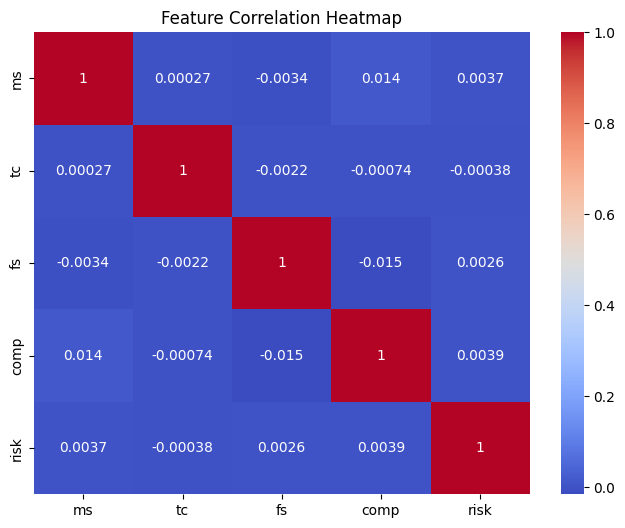

In [19]:
heatmap_df = df[['ms','tc','fs','comp']].copy()
heatmap_df['risk'] = LabelEncoder().fit_transform(df['risk'])
plt.figure(figsize=(8,6))
sns.heatmap(heatmap_df.corr(),annot=True,cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [20]:
# COMBINE FEATURES

X = sp.hstack([X_text,df[['ms','tc','fs','comp']].values])

In [21]:
# TARGET

le = LabelEncoder()
y = le.fit_transform(df['risk'])

In [22]:
# SPLIT

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [23]:
# MODEL

model = DecisionTreeClassifier(max_depth=6,min_samples_split=10,min_samples_leaf=5,random_state=42)
model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=6, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [24]:
# EVALUATION

y_pred = model.predict(X_test)
print("Accuracy : ",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy :  0.8218571428571428
              precision    recall  f1-score   support

           0       0.92      0.60      0.73      7085
           1       0.83      0.95      0.89     28023
           2       0.78      0.72      0.75     20892

    accuracy                           0.82     56000
   macro avg       0.85      0.76      0.79     56000
weighted avg       0.82      0.82      0.82     56000



In [25]:
import joblib

In [26]:
joblib.dump({
    "model":model,
    "vectorizer":vectorizer,
    "label_encoder":le,
    "ms_encoder":le1,
    "tc_encoder":le2,
    "fs_encoder":le3,
    "comp_encoder":le4
},"best.pkl")

print("All saved in best.pkl")

All saved in best.pkl


In [27]:
# # ================================
# # EXTRA FEATURES (UPGRADE)
# # ================================

# # Confidence score
# probs = model.predict_proba(X_test)
# confidence = np.max(probs, axis=1)

# # Convert numeric prediction back to label
# pred_labels = le.inverse_transform(y_pred)

# # Risk message
# def risk_message(risk):
#     if risk == "Low":
#         return "Startup idea has good potential ✅"
#     elif risk == "Medium":
#         return "Moderate risk, needs validation ⚠"
#     else:
#         return "High risk, rethink strategy ❌"

# # Team suggestion
# def suggest_team(tc_value):
#     if tc_value == "Low":
#         return "2-4 members"
#     elif tc_value == "Medium":
#         return "4-6 members"
#     else:
#         return "6-10 members"

# # Show some sample outputs
# for i in range(5):
#     print("\n🔹 Startup Idea Result")
#     print("Risk:", pred_labels[i])
#     print("Confidence:", round(confidence[i],2))
#     print("Message:", risk_message(pred_labels[i]))

In [28]:
# CROSS VALIDATION

cv_scores = cross_val_score(model,X,y,cv=5)
print("CV Accuracy : ",np.mean(cv_scores))

CV Accuracy :  0.8224107142857143
